# Assignment 1 Perceptron Image Classification
### Arseniy Uspenskiy
### USPARS001

Importing necessary packages

In [1]:
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import itertools

## Data Processing

Creating method for loading all images of a specified directory

Images are flattened into vectors and returned alongside their character label

In [2]:
CHARACTERS = ["bart_simpson", "charles_montgomery_burns", "homer_simpson",
    "krusty_the_clown", "lisa_simpson", "marge_simpson",
    "milhouse_van_houten", "moe_szyslak", "ned_flanders", "principal_skinner"]

# Method for loading images from a particular directory e.g.(rgb-train)
def load_dataset(path : str):

    vectors = []
    labels = []

    for name in CHARACTERS:
        char_dir = os.path.join(path, name)

        for file in os.listdir(char_dir):

            img_path = os.path.join(char_dir, file)
            img = Image.open(img_path)
            arr = np.array(img)
            vectors.append(arr.flatten())
            labels.append(CHARACTERS.index(name))

    x = np.array(vectors)
    y = np.array(labels)

    return x, y

Loading seperate training, validation, and test datasets for both rgb and grayscale

In [3]:
X_train_gray_full, y_train_gray_full = load_dataset("datasets/grayscale/train")
X_test_gray, y_test_gray = load_dataset("datasets/grayscale/test")

X_train_rgb_full, y_train_rgb_full = load_dataset("datasets/rgb/train")
X_test_rgb, y_test_rgb = load_dataset("datasets/rgb/test")

X_train_gray, X_val_gray, y_train_gray, y_val_gray = train_test_split(X_train_gray_full, y_train_gray_full, test_size=0.2, stratify=y_train_gray_full, random_state=42)
X_train_rgb, X_val_rgb, y_train_rgb, y_val_rgb = train_test_split(X_train_rgb_full, y_train_rgb_full, test_size=0.2, stratify=y_train_rgb_full, random_state=42)

## Multi-class perceptron implementation

BinaryPerceptron with a score method for evaluating a confidence in a guess and a predict for outputting 0 or 1 which is used for training by the learning rule

In [4]:

class BinaryPerceptron:

    def __init__(self, id: int, n: int, alpha: float, init: np.array):
        self.id = id
        self.weights = np.ones(n, dtype=float) * init
        self.bias = 0.1
        self.alpha = alpha

    def score(self, x : np.array) -> float:
            weighted_sum = np.dot(x, self.weights) + self.bias
            return weighted_sum

    def predict(self, x : np.array) -> int:
        return 1 if self.score(x) >= 0 else 0

    def learning_rule(self, x, y):
        g = self.predict(x)
        self.weights = self.weights + self.alpha * (y - g) * (x)
        self.bias = self.bias + self.alpha * (y - g)

    def __repr__(self):
        return CHARACTERS[self.id] + " Perceptron"

MultiClassPerceptron which utilizes a one versus rest approach using 10 binary perceptrons to classify images

has a predict method which outputs a predicted value 0-9 based on a provided flattened image np.array

train perceptron runs the learning rule for each perceptron on each data point provided

In [5]:
class MultiClassPerceptron:

    def __init__(self, n: int, alpha: float, init: float):
        self.perceptrons = [BinaryPerceptron(i, n, alpha, init) for i in range(10)]

    def predict(self, x) -> float:
        top_score = float("-inf")
        top_num = 0
        for i in range(len(self.perceptrons)):
            y = self.perceptrons[i].score(x)
            if y > top_score:
                top_score = y
                top_num = i

        return top_num

    def train_perceptron(self, X : np.array, y : np.array):
        for i in range(len(X)):
            for percep in self.perceptrons:
                y_converted = 0
                if percep.id == y[i]:
                    y_converted = 1
                percep.learning_rule(X[i], y_converted)


## Training

Method for assesing accuracy of a perceptron

In [6]:
def accuracy(perceptron: MultiClassPerceptron, data_X : np.array, data_y : np.array) -> float:
    correct = 0
    total = 0

    for X, y in zip(data_X, data_y):
        y_hat = perceptron.predict(X)
        if y_hat == y:
            correct += 1
        total += 1

    accuracy = correct / total
    return accuracy

Method for training Perceptron over multiple epochs, setting alpha, initialization values as well as the normalization of the data

gray and rgb perceptrons are trained in parallel

Exit Conditions: max epochs reached or streak of no improvements in accuracy

outputs a 14 element tuple containing alternating information of the gray and rgb preceptron

In [7]:
def test_perceptron(alpha: float, init, norm, min_delta=0.0001, patience=5, seed=25):
    p_gray = MultiClassPerceptron(len(X_train_gray[0]), alpha, init(X_train_gray))
    p_rgb = MultiClassPerceptron(len(X_train_rgb[0]), alpha, init(X_train_rgb))
    epochs = 30
    x_gray = []
    y_gray = []
    x_rgb = []
    y_rgb = []

    best_acc_gray, best_acc_rgb = 0.0, 0.0
    no_improve_gray, no_improve_rgb = 0, 0
    stopped_gray, stopped_rgb = False, False
    stop_epoch_gray, stop_epoch_rgb = epochs, epochs

    rng = np.random.default_rng(seed)

    for epoch in range(epochs):

        perm = rng.permutation(len(X_train_gray))
        X_train_gray_shuff = norm(X_train_gray[perm])
        y_train_gray_shuff = y_train_gray[perm]
        X_train_rgb_shuff = norm(X_train_rgb[perm])
        y_train_rgb_shuff = y_train_rgb[perm]

        X_val_gray_norm = norm(X_val_gray)
        X_val_rgb_norm = norm(X_val_rgb)

        if not stopped_gray:
            p_gray.train_perceptron(X_train_gray_shuff, y_train_gray_shuff)
            acc_gray = accuracy(p_gray, X_val_gray_norm, y_val_gray)
            x_gray.append(epoch + 1)
            y_gray.append(acc_gray)

            if acc_gray - best_acc_gray > min_delta:
                best_acc_gray = acc_gray
                no_improve_gray = 0
            else:
                no_improve_gray += 1

            if no_improve_gray >= patience:
                stopped_gray = True
                stop_epoch_gray = epoch + 1

        if not stopped_rgb:
            p_rgb.train_perceptron(X_train_rgb_shuff, y_train_rgb_shuff)     
            acc_rgb = accuracy(p_rgb, X_val_rgb_norm, y_val_rgb)
            x_rgb.append(epoch+1)
            y_rgb.append(acc_rgb)

            if acc_rgb - best_acc_rgb > min_delta:
                best_acc_rgb = acc_rgb
                no_improve_rgb = 0
            else:
                no_improve_rgb += 1
            
            if no_improve_rgb >= patience:
                stopped_rgb = True
                stop_epoch_rgb = epoch + 1

        if stopped_gray and stopped_rgb:
            break

    text_gray = f"Final accuracy gray: {acc_gray}, a: {alpha}, init: {init}, norm: {norm}"
    text_rgb = f"Final accuracy rgb: {acc_rgb}, a: {alpha}, init: {init}, norm: {norm}"
    params = [alpha, init, norm]

    print(text_gray)
    print(text_rgb)
    print()

    return acc_gray, acc_rgb, x_gray, x_rgb, y_gray, y_rgb, stop_epoch_gray, stop_epoch_rgb, text_gray, text_rgb, params, params, p_gray, p_rgb

Class for better utilization of functions

allows for printing a function to output the function's name as a string

In [8]:
class CustomFunction:
    def __init__(self, func, custom_message):
        self.func = func
        self.custom_message = custom_message

    def __call__(self, *args, **kwargs):
        return self.func(*args, **kwargs)

    def __repr__(self):
        return self.custom_message

Functions for data initialization

In [9]:
def uniform(X: np.array, seed: int = 25) -> np.array:
    rng = np.random.default_rng(seed)
    return rng.uniform(low=-0.01, high=0.01, size=(len(X[0])))

cust_uniform = CustomFunction(uniform, "Uniform")

def guassian(X: np.array, seed: int = 25) -> np.array:
    rng = np.random.default_rng(seed)
    return rng.normal(loc=0.0, scale=0.01, size=len(X[0]))

cust_guassian = CustomFunction(guassian, "Guassian")

def zeros(X: np.array) -> np.array:
    return np.zeros(len(X[0]))

cust_zeros = CustomFunction(zeros, "Zero")

Functions for data normalization/standardization

In [10]:
def normalize(X : np.array) -> np.array:
    return X / 255.0

cust_normalize = CustomFunction(normalize, "Normalize")

def standardize(X : np.array) -> np.array:
    standardized_X = []
    mean = np.mean(X)
    std = np.std(X)
    for elem in X:
        standardized_X.append((elem - mean) / std)

    return np.array(standardized_X)

cust_standardize = CustomFunction(standardize, "Standardize")

def default(X: np.array) -> np.array:
    return X

cust_default = CustomFunction(default, "None")

Function for Plotting Learning Data

In [11]:

def show_graph(X: np.array, y: np.array):
    plt.plot(X, y, marker='o')
    plt.xlim(0, 30)
    plt.ylim(0, 0.60) 
    plt.show()

Loop for Testing Perceptrons on different combinations of alpha values and normalization methods

contains all three covered initialization and normalization approaches, as well as a large range of alpha values

Final accuracy gray: 0.20625, a: 0.5, init: Zero, norm: None
Final accuracy rgb: 0.34875, a: 0.5, init: Zero, norm: None

Final accuracy gray: 0.20625, a: 0.5, init: Zero, norm: Normalize
Final accuracy rgb: 0.3975, a: 0.5, init: Zero, norm: Normalize

Final accuracy gray: 0.21625, a: 0.5, init: Zero, norm: Standardize
Final accuracy rgb: 0.368125, a: 0.5, init: Zero, norm: Standardize

Final accuracy gray: 0.206875, a: 0.5, init: Uniform, norm: None
Final accuracy rgb: 0.36375, a: 0.5, init: Uniform, norm: None

Final accuracy gray: 0.2125, a: 0.5, init: Uniform, norm: Normalize
Final accuracy rgb: 0.398125, a: 0.5, init: Uniform, norm: Normalize

Final accuracy gray: 0.21, a: 0.5, init: Uniform, norm: Standardize
Final accuracy rgb: 0.36125, a: 0.5, init: Uniform, norm: Standardize

Final accuracy gray: 0.2075, a: 0.5, init: Guassian, norm: None
Final accuracy rgb: 0.380625, a: 0.5, init: Guassian, norm: None

Final accuracy gray: 0.191875, a: 0.5, init: Guassian, norm: Normalize
Fin

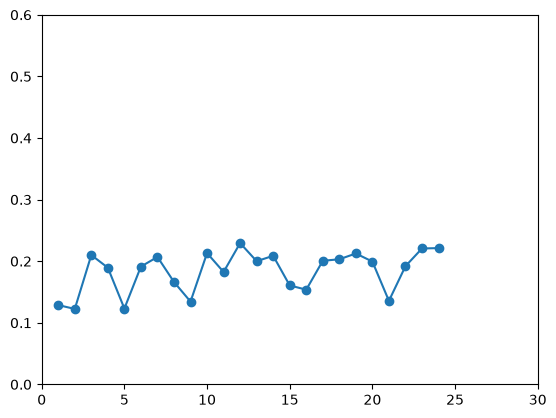

RGB Graph Stop Epoch: 19
Final accuracy rgb: 0.418125, a: 0.1, init: Guassian, norm: Normalize


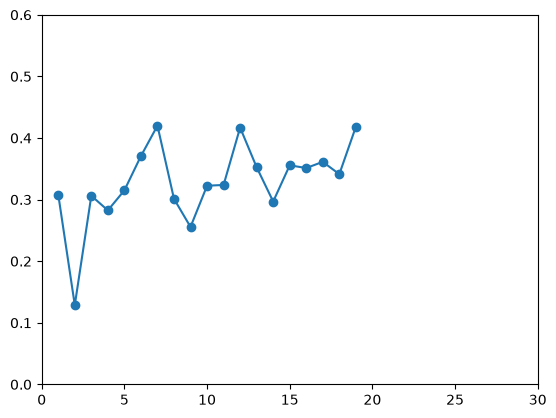

In [12]:
alphas = [0.5, 0.1, 0.05, 0.01, 0.005]
inits = [cust_zeros, cust_uniform, cust_guassian]
norms = [cust_default, cust_normalize, cust_standardize]
tests = itertools.product(alphas, inits, norms)

max_rgb = [0]
max_gray = [0]

for test in tests:

    output = test_perceptron(*test, 0.0001, 12)

    if output[0] > max_gray[0]:
        max_gray = output[::2]
    if output[1] > max_rgb[0]:
        max_rgb = output[1::2]

print(f"Gray Graph Stop Epoch: {max_gray[3]}")
print(max_gray[4])
show_graph(max_gray[1], max_gray[2])
print(f"RGB Graph Stop Epoch: {max_rgb[3]}")
print(max_rgb[4])
show_graph(max_rgb[1], max_rgb[2])

Method for evaluating a model

outputs accuracy, confustion matrix and a report

In [13]:
def evaluate(preceptron: MultiClassPerceptron, X_data, y_data):
    y_pred = []

    for i in range(len(X_data)):
        y_pred.append(preceptron.predict(X_data[i]))

    y_pred = np.array(y_pred)

    acc = accuracy_score(y_data, y_pred)
    cm = confusion_matrix(y_data, y_pred, labels=range(len(CHARACTERS)))
    report = classification_report(y_data, y_pred, labels=range(len(CHARACTERS)), target_names=CHARACTERS, zero_division=0)

    print(f"Accuracy: {acc:.3f}\n")
    print(report)

    return acc, cm, report

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CHARACTERS)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

Evaluating two best models

Accuracy: 0.156

                          precision    recall  f1-score   support

            bart_simpson       0.11      0.07      0.09       360
charles_montgomery_burns       0.59      0.03      0.05       360
           homer_simpson       0.15      0.32      0.20       360
        krusty_the_clown       0.26      0.08      0.13       360
            lisa_simpson       0.13      0.78      0.22       360
           marge_simpson       0.31      0.04      0.07       360
     milhouse_van_houten       0.30      0.05      0.09       360
             moe_szyslak       0.31      0.12      0.18       360
            ned_flanders       0.00      0.00      0.00       360
       principal_skinner       0.49      0.06      0.10       360

                accuracy                           0.16      3600
               macro avg       0.26      0.16      0.11      3600
            weighted avg       0.26      0.16      0.11      3600

Accuracy: 0.395

                          precision    

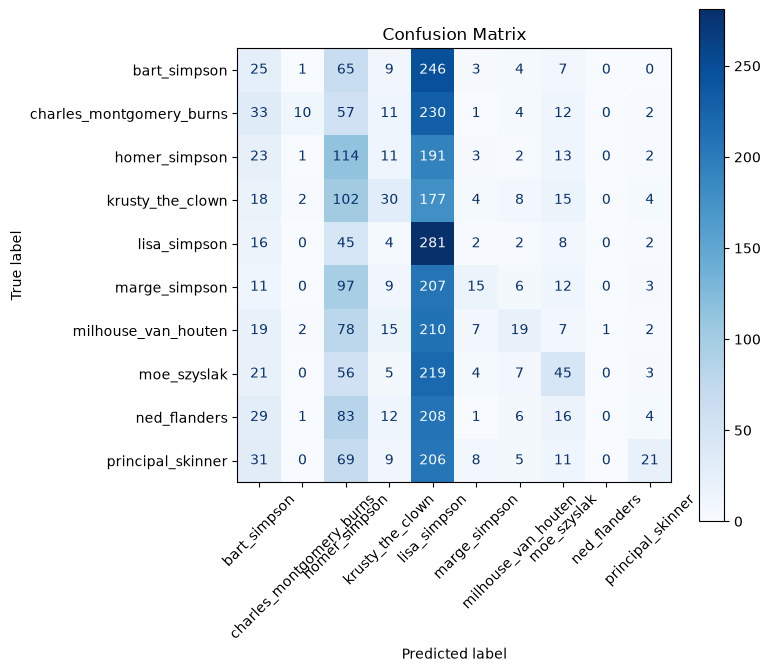

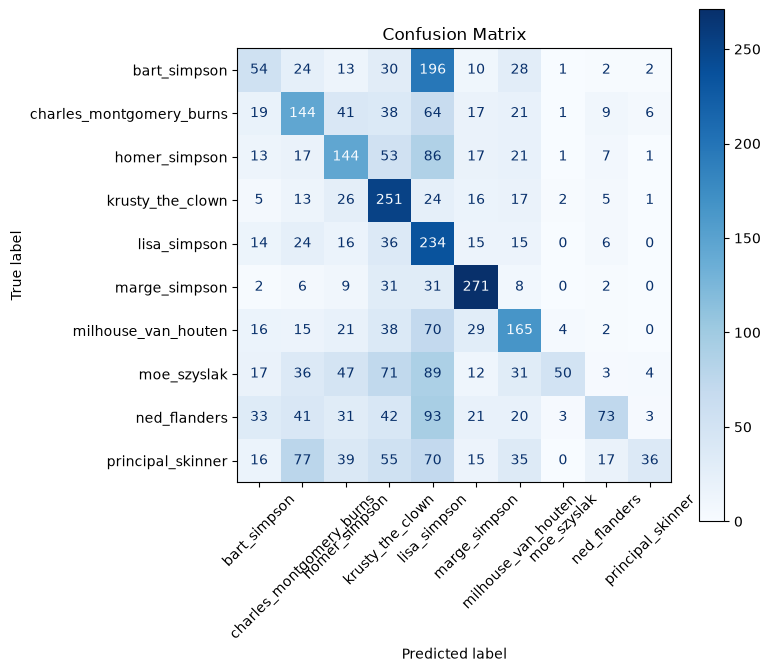

In [14]:
acc_g, cm_g, report_g = evaluate(max_gray[-1], np.concatenate((X_val_gray, X_test_gray), axis=0), np.concatenate((y_val_gray, y_test_gray), axis=0))
acc_rgb, cm_rgb, report_rgb = evaluate(max_rgb[-1], np.concatenate((X_val_rgb, X_test_rgb), axis=0), np.concatenate((y_val_rgb, y_test_rgb), axis=0))

plot_confusion_matrix(cm_g)
plot_confusion_matrix(cm_rgb)

Creating new modified brightness and rotation training sets, and a modified training method

Two new pairs of arrays are created each contating the original rgb data concatenated with data that had augmented brightness range:[0.7,1.3] and augmented rotation range:[-15,15]

Training method only usable on a single perceptron at a time

In [15]:
def augment_bright(images, low=0.7, high=1.3, seed=25):
    rng = np.random.default_rng(seed)
    aug_arr = np.empty((len(images), images.shape[1] * images.shape[2] * images.shape[3]), dtype=images.dtype)

    for i in range(len(images)):
        b = rng.uniform(low, high)
        bright = np.clip(images[i].astype(float) * b, 0, 255).astype(np.uint8)
        aug_arr[i] = bright.flatten()

    return aug_arr

def augment_rotation(images, low=-15, high=15, seed=25):
    rng = np.random.default_rng(seed)
    aug_arr = np.empty((len(images), images.shape[1] * images.shape[2] * images.shape[3]), dtype=images.dtype)

    for i in range(len(images)):
        angle = rng.uniform(low, high)
        rotated = Image.fromarray(images[i]).rotate(angle)
        aug_arr[i] = np.array(rotated).flatten()
    
    return aug_arr

side = int(np.sqrt(X_train_rgb.shape[1] // 3))
X_train_rgb_raw = X_train_rgb.reshape(-1, side, side, 3).astype(np.uint8)

X_train_brightness = np.concatenate((X_train_rgb, augment_bright(X_train_rgb_raw)), axis=0)
y_train_brightness = np.concatenate((y_train_rgb, y_train_rgb), axis=0)

X_train_rotation = np.concatenate((X_train_rgb, augment_rotation(X_train_rgb_raw)), axis=0)
y_train_rotation = np.concatenate((y_train_rgb, y_train_rgb), axis=0)

def test_one_perceptron(X_data, y_data, alpha: float, init: CustomFunction, norm: CustomFunction, min_delta=0.0001, patience=5, seed=25):
    p = MultiClassPerceptron(len(X_data[0]), alpha, init(X_data))
    epochs = 30
    x = []
    y = []
    
    best_acc = 0.0
    no_improve = 0
    stopped = False
    stop_epoch = epochs
    
    rng = np.random.default_rng(seed)

    for epoch in range(epochs):
    
        perm = rng.permutation(len(X_data))

        X_train_shuff = norm(X_data[perm])
        y_train_shuff = y_data[perm]
        
        X_val_norm = norm(X_val_rgb)
        
                
        if not stopped:
            p.train_perceptron(X_train_shuff, y_train_shuff)     
            acc = accuracy(p, X_val_norm, y_val_rgb)
            x.append(epoch+1)
            y.append(acc)
    
        if acc - best_acc > min_delta:
            best_acc = acc
            no_improve = 0
        else:
            no_improve += 1
                                
        if no_improve >= patience:
            stopped = True
            stop_epoch = epoch + 1
                    
        if stopped:
            break
                    
    text = f"Final accuracy: {acc}, a: {alpha}, init: {init}, norm: {norm}"
                    
    print(text)
    print()
                    
    return acc, x, y, stop_epoch, text, p

Training on all three unique training sets

In [16]:
seeds = [5, 12, 17, 20, 32]
output_new = [[], [], []]
data = [[X_train_rgb, y_train_rgb], [X_train_brightness, y_train_brightness], [X_train_rotation, y_train_rotation]]

for i in range(3):
    for s in seeds:
        output_new[i].append(test_one_perceptron(data[i][0], data[i][1], *max_rgb[-2], 0.0001, 5, s))

Final accuracy: 0.39625, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.326875, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.28625, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.351875, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.4, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.349375, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.345625, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.295625, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.38, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.356875, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.2225, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.331875, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.32625, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.335, a: 0.1, init: Guassian, norm: Normalize

Final accuracy: 0.360625, a: 0.1, init: Guassian, norm: Normalize



Showing comparison of values from all three different training sets

In [17]:
names = ["Original", "Brightness", "Rotation"]
data = [[X_val_rgb, y_val_rgb], [X_test_rgb, y_test_rgb]]
summary = []

for d in data:
    for i, name in enumerate(names):
        accuracies = []
        confusions = []

        for run in output_new[i]:
            p = run[-1]

            acc, cm, report = evaluate(p, d[0], d[1])

            accuracies.append(acc)
            confusions.append(cm)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        mean_cm = np.mean(confusions, axis=0)

        summary.append({"dataset": name, "mean_accuracy": mean_acc, "std_accuracy": std_acc, "mean_confusion_matrix": mean_cm})

        print(f"{name}: {mean_acc:.3f} ± {std_acc:.3f}")

Accuracy: 0.374

                          precision    recall  f1-score   support

            bart_simpson       0.34      0.38      0.36       160
charles_montgomery_burns       0.79      0.09      0.17       160
           homer_simpson       0.26      0.56      0.35       160
        krusty_the_clown       0.55      0.51      0.53       160
            lisa_simpson       0.57      0.08      0.14       160
           marge_simpson       0.32      0.89      0.47       160
     milhouse_van_houten       0.82      0.14      0.24       160
             moe_szyslak       0.33      0.53      0.40       160
            ned_flanders       0.64      0.21      0.32       160
       principal_skinner       0.56      0.34      0.42       160

                accuracy                           0.37      1600
               macro avg       0.52      0.37      0.34      1600
            weighted avg       0.52      0.37      0.34      1600

Accuracy: 0.296

                          precision    